In [15]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv

pass question as input state - > llm answer and update state and return
add nodes and adges and compile and invoke to run

In [16]:
load_dotenv()

True

In [27]:
# define state

class LLMState(TypedDict):

    question : str
    answer : str


# define node
def get_answer(state: LLMState) -> LLMState:
    question = state['question']

    PROMPT = f'Answer to the user question in concise {question}'

    llm = ChatGroq(
        model="llama-3.3-70b-versatile",   # Best model on Groq right now
        temperature=0.0,
        max_tokens=512,
    )

    answer = llm.invoke(PROMPT).content

    state['answer'] = answer

    return state


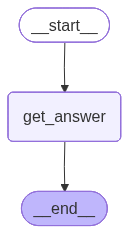

In [28]:
# define graph

graph = StateGraph(LLMState)


# add node and adge
graph.add_node('get_answer', get_answer)

graph.add_edge(START, 'get_answer')
graph.add_edge('get_answer',END)

workflow = graph.compile()
workflow

In [29]:
input = {'question': 'what is llm? '}

output_state = workflow.invoke(input)
output_state

{'question': 'what is llm? ',
 'answer': 'LLM stands for Large Language Model, a type of artificial intelligence (AI) designed to process and understand human language.'}

In [32]:
output_state['answer']

'LLM stands for Large Language Model, a type of artificial intelligence (AI) designed to process and understand human language.'